# <b>[공모전] RNN 시계열 날씨 예측

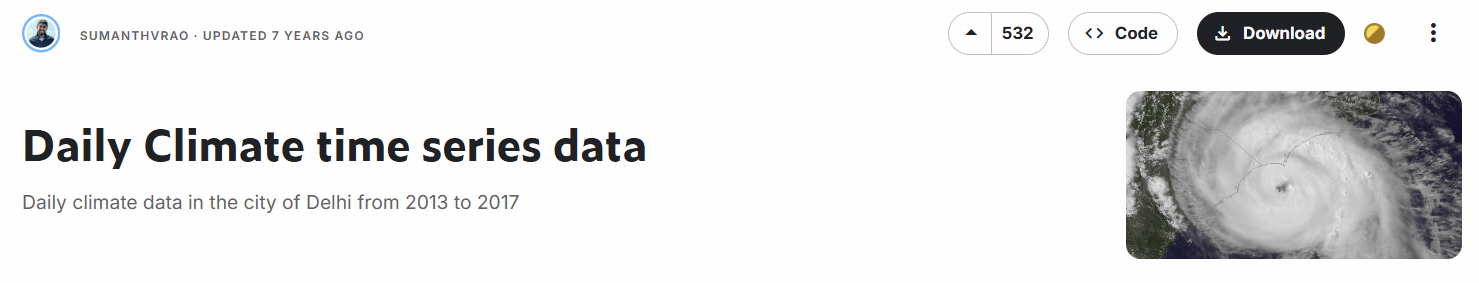
* https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dropout, GRU, Bidirectional
from tensorflow.keras.layers import Flatten, Dense, Rescaling
from tensorflow.keras.initializers import GlorotNormal    #Xavier

import math
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler


#----------------------------------------------------------------------------------  랜덤시드 고정 
import tensorflow as tf
tf.random.set_seed(54546)
np.random.seed(54546)

#----------------------------------------------------------------------------------  조기종료
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
    

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b>Data Load

In [2]:
dataset = pd.read_csv('./dataset/DailyDelhiClimateTrain.csv', parse_dates=['date'])
test = pd.read_csv('./dataset/DailyDelhiClimateTest.csv', parse_dates=['date'])

In [4]:
dataset.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [5]:
test.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


train(1402일) - train(80%), val(20%)
test(60일)

# <b>train_test_split

In [6]:
test = dataset[-30:]
len(dataset), len(test)

(1462, 30)

In [7]:
train, val = train_test_split(dataset[ :-len(test)], test_size = 0.2, shuffle=False)
len(train), len(val)

(1145, 287)

# <b>EDA

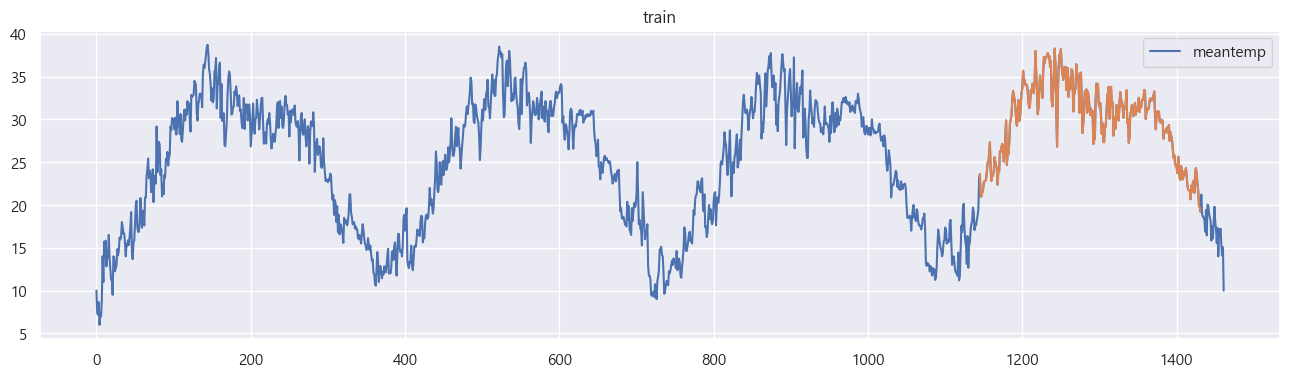

In [8]:
dataset['meantemp'].plot(figsize=(16,4), legend=True)
dataset['meantemp'][len(train): len(train)+ len(val)].plot(figsize=(16, 4), )

plt.title('train')
plt.show()

# <b>전처리 & 가공

## <b>파생피쳐

## <b>스케일링

In [9]:
train.shape, train[:2]

((1145, 5),
         date  meantemp  humidity  wind_speed  meanpressure
 0 2013-01-01      10.0      84.5        0.00   1015.666667
 1 2013-01-02       7.4      92.0        2.98   1017.800000)

In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1145 entries, 0 to 1144
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1145 non-null   datetime64[ns]
 1   meantemp      1145 non-null   float64       
 2   humidity      1145 non-null   float64       
 3   wind_speed    1145 non-null   float64       
 4   meanpressure  1145 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 53.7 KB


In [12]:
# date를 인덱스로 설정
train = train.set_index('date')

# 이제 모든 컬럼이 숫자이므로 바로 스케일링 가능
sc = MinMaxScaler()
train_scaled = sc.fit_transform(train)


## <b>윈도우 슬라이딩

In [13]:
X_train = []
y_train = []
window_size = 7
for i in range(0,1145-window_size):
    X_train.append(train_scaled[i:i+window_size , 0])
    y_train.append(train_scaled[i+window_size , 0])
X_train, y_train = np.array(X_train), np.array(y_train)

print( X_train.shape, y_train.shape)
print( X_train[:1] )

(1138, 7) (1138,)
[[0.12227074 0.04279476 0.0356623  0.08151383 0.         0.03056769
  0.03056769]]


## <font color=red><b>input_shape : 3D
* samples : 데이터 갯수
* timestep : window_size
* features : 변수갯수 == df['cnt']

In [14]:
X_train = X_train.reshape( X_train.shape[0] ,  X_train.shape[1],  1)    
                          # 샘플수          피쳐갯수(window_size)  'High'변수
X_train.shape

(1138, 7, 1)

# <b>모델 & 평가

(R)MSE : 단순 수치 차이
(R)MSLogE : 비율(증강률)이 중요

증감율에 대한 오차를 계산하고 싶은 경우
작은 수치의 오차에 민감하게 반응해야 하는 경우
성장률/비율이 중요한 경우 - 매출/재고 증강률, 환율, 금리(이자율)
음수값 계산 불가

 y       pred     mse        
100    110      10     ---   10%
1000  1010     10    ---     1%

| 지표 | 수식 (Formula) | 특징 및 용도 | 비고 |
| :--- | :---: | :--- | :--- |
| **MSE** | $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$ | 오차를 제곱하여 계산. 큰 오차에 매우 민감함. | 학습용 **Loss**로 주로 사용 |
| **RMSE** | $\sqrt{\frac{1}{n} \sum (y_i - \hat{y}_i)^2}$ | MSE에 루트를 씌움. 실제 데이터와 단위가 일치함. | 일반적인 성능 **Metric** |
| **RMSLE** | $\sqrt{\frac{1}{n} \sum (\log(y_i+1) - \log(\hat{y}_i+1))^2}$ | 로그를 씌워 계산. 상대적 비율 오차를 측정함. | 아웃라이어가 많을 때 유리 |

In [15]:
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(7,1)) ,  #X_train.shape[1],1
    Dropout(0.2)  ,
    LSTM(units=50, return_sequences=True)  ,
    Dropout(0.2)  ,
    LSTM(units=50, return_sequences=True) ,
    Dropout(0.2) ,
    LSTM(units=50) ,
    Dropout(0.2) ,
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mse')
fit_res = model.fit(X_train,y_train, epochs=10, batch_size=128)  #callback=[MY_CHECK_POINT, MY_STOP]

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2934
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0691
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0322
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0277
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0220
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0182
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0142
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0120
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0114
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0104


# <b>답안지 제출

In [16]:
len(dataset), len(train),  len(val) , val.shape, len(test)

(1462, 1145, 287, (287, 5), 30)

In [17]:
# date를 인덱스로 설정
val = val.set_index('date')

# 이제 모든 컬럼이 숫자이므로 바로 스케일링 가능
sc = MinMaxScaler()
val_scaled = sc.fit_transform(val)


In [19]:
X_val = []
y_val = []
window_size = 7
for i in range(0,287-window_size):
    X_val.append(val_scaled[i:i+window_size , 0])
    y_val.append(val_scaled[i+window_size , 0])
X_val, y_val = np.array(X_val), np.array(y_val)

print( X_val.shape, y_val.shape)
print( X_val[:1] )

(280, 7) (280,)
[[0.23167097 0.09397973 0.09397973 0.11645994 0.13004172 0.1759388
  0.18839658]]


In [25]:
def plot_predictions(test,predicted):
    plt.figure(figsize=(7,2))
    plt.plot(test, color='red',label='Real')
    plt.plot(predicted, color='blue',label='Predicted')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


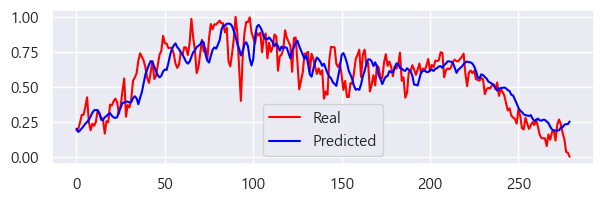

In [26]:
pred = model.predict(X_val)
plot_predictions(y_val,pred)

In [27]:
return_rmse(y_val,pred)

The root mean squared error is 0.12025249750236015.


In [28]:
# date를 인덱스로 설정
test = test.set_index('date')

# 이제 모든 컬럼이 숫자이므로 바로 스케일링 가능
sc = MinMaxScaler()
test_scaled = sc.fit_transform(test)


In [31]:
X_test = []
y_test = []
window_size = 7
for i in range(0,30-window_size):
    X_test.append(test_scaled[i:i+window_size , 0])
    y_test.append(test_scaled[i+window_size , 0])
X_test, y_test = np.array(X_test), np.array(y_test)

print( X_test.shape, y_test.shape)
print( X_test[:1] )

(23, 7) (23,)
[[1.         0.79405204 0.77053058 0.76179582 0.73605948 0.61561338
  0.8401487 ]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


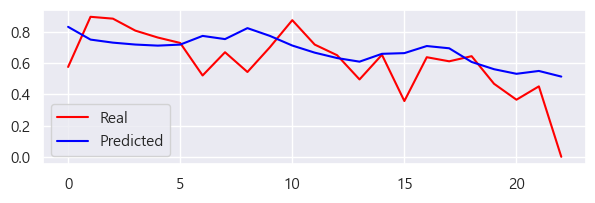

The root mean squared error is 0.17887552914031749.


In [32]:
pred = model.predict(X_test)
plot_predictions(y_test,pred)
return_rmse(y_test,pred)